# W2246-0526 — N.E.M.O. Pipeline

Per-channel starlet wavelet detection + masked TV-L1 optical flow tracking using the `nemo` package.

## Imports

In [12]:
%matplotlib inline
from __future__ import annotations

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from pathlib import Path

from nemo import (
    WaveletDetector,
    FlowTracker,
    load_cube,
    active_channels,
)
from astropy.io import fits as _afits
from astropy.wcs import WCS as _WCS
from astropy.cosmology import Planck18 as _Planck18
import astropy.units as _u


## Cube Loader

Load the W2246-0526 [C II] 158 µm ALMA cube and select active channels.

In [15]:
USE_DENOISED = True

_RAW_FITS      = '/Users/arnablahiry/repos/IFU-Source-ID/data/observed_cubes/CROPPED_ONLY_SPATIAL_W2246_CII_314.fits'
_DENOISED_FITS = '/Users/arnablahiry/repos/IFU-Source-ID/data/observed_cubes/CROPPED_ONLY_SPATIAL_W2246_CII_314_denoised_ist.fits'
_CUBE_PATH     = _DENOISED_FITS if USE_DENOISED else _RAW_FITS
_label         = 'IST-denoised' if USE_DENOISED else 'raw noisy'

# Load cube via storm (handles HDF5/FITS/npy/npz, nan→0, float32)
cube = load_cube(_CUBE_PATH)
np.clip(cube, 0.0, None, out=cube)   # negative flux is non-physical

# Load FITS header separately for WCS
with _afits.open(_CUBE_PATH) as _hdul:
    _hdr = _hdul[0].header.copy()

n_ch, H, W = cube.shape
_RESULTS_DIR = f'../results/w2246_{n_ch}'
print(f'W2246 {_label} cube : {cube.shape}')
print(f'Flux range          : [{cube.min():.3e}, {cube.max():.3e}]')
print(f'Noise std (global)  : {cube.std():.3e}')

# Active channels
channel_list = active_channels(cube, threshold_frac=0.16)
channel_list = list(range(max(0, channel_list[0] - 10),
                          min(n_ch, channel_list[-1] + 6)))
print(f'Active channels     : {len(channel_list)}')

# Detection floor
thresh_frac  = 0.005
W2246_THRESH = thresh_frac * float(cube.max())
print(f'Detection floor     : {W2246_THRESH:.3e}  ({thresh_frac} x cube.max())')

# Spectral WCS -> velocity array
_crval3  = float(_hdr['CRVAL3'])
_cdelt3  = float(_hdr['CDELT3'])
_crpix3  = float(_hdr['CRPIX3'])
_restfrq = float(_hdr['RESTFRQ'])
_C_KMS   = 299792.458
_freq_arr = _crval3 + _cdelt3 * (np.arange(n_ch) - (_crpix3 - 1))
vel_array = _C_KMS * (_restfrq - _freq_arr) / _restfrq
print(f'Velocity range : [{vel_array.min():.1f}, {vel_array.max():.1f}] km/s')

# 2-D celestial WCS and pixel scale in kpc
_wcs2d        = _WCS(_hdr).celestial
_z            = 4.6
_pixscale_deg = abs(float(_hdr['CDELT1']))
_pixscale_as  = _pixscale_deg * 3600
_kpc_per_as   = _Planck18.kpc_proper_per_arcmin(_z).to('kpc/arcsec').value
pixscale_kpc  = _pixscale_as * _kpc_per_as
print(f'Pixel scale    : {pixscale_kpc:.3f} kpc/px')


W2246 IST-denoised cube : (288, 138, 138)
Flux range          : [0.000e+00, 1.015e-02]
Noise std (global)  : 2.785e-04
Active channels     : 183
Detection floor     : 5.073e-05  (0.005 x cube.max())
Velocity range : [-1427.0, 1443.0] km/s
Pixel scale    : 0.334 kpc/px


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


## N.E.M.O. Pipeline

Configure `WaveletDetector` and `FlowTracker`, then call `tracker.run()`. `result.sources` contains only real sources (false detections already removed).


╔═══════════════════════════════╗
║ ⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣼⣿⣷⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀ ║
║ ⠀⠀⠀⠀⠀⠀⠀⣀⣀⡀⠀⠀⠀⣿⣿⣿⣿⣿⣆⠀⠀⠀⠀⠀⠀⠀ ║
║ ⠀⠀⠀⠀⠀⠀⢰⣿⣿⣿⣷⡆⢀⣿⣿⣿⣿⣿⡿⠁⣠⣄⠀⠀⠀⠀ ║
║ ⠀⣠⣀⠀⠀⠀⠈⢛⣿⣿⣿⠁⣸⣿⣿⣿⣿⣿⠃⢰⣿⣿⣷⣄⠀⠀ ║
║ ⢰⣿⣿⣿⠀⢰⣶⣿⣿⣿⡇⠀⣿⣿⣿⣿⣿⣿⠀⢸⡟⠉⠙⣿⣷⠀ ║
║ ⢸⣿⣿⣿⠀⢸⣿⣿⣿⣿⡇⢰⣿⣿⣿⣿⣿⣿⠀⢸⣷⣤⣴⣿⣿⡇ ║
║ ⠸⣿⣿⣿⠀⠸⢿⣿⣿⣿⡇⠀⣿⣿⣿⣿⣿⣿⠀⢸⣿⣿⣿⣿⡿⠀ ║
║ ⠀⠙⠉⠀⠀⢠⣾⣿⣿⣿⣿⡀⢻⣿⣿⣿⣿⣿⡄⠸⣿⣿⣿⠛⠀⠀ ║
║ ⠀⠀⠀⠀⠀⠸⣿⣿⣿⣿⡿⠇⠘⣿⣿⣿⣿⣿⡷⠀⠙⠋⠀⠀⠀⠀ ║
║ ⠀⠀⠀⠀⠀⠀⠈⠉⠉⠁⠀⠀⠀⣿⣿⣿⡿⠟⠀⠀⠀⠀⠀⠀⠀⠀ ║
║ ⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠘⠛⠋⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀ ║
╚══════════════════════════════╝

[Stage 1] Computing masked TV-L1 optical flow for 182 channel pairs...
  → 182 flow pairs computed.

[Stage 2] Linking tracks across 183 channels (182 transitions)...
  Seeded 0 track(s) from channel 47 (0 component(s))
  → 17 total tracks created.

[Stage 3] Kinematic classification  (min_displacement=3.0 px)
  track  0  kinematic  ch 56–73  disp=3.0 px
  track  1  kinematic  ch 57–229  disp=29.4 px
  track  2  static     ch 57–64  displacement below threshold
  track  3  kinematic  ch 132–176  disp=29.8 px
  track  4  static     ch 163–168  displacement below threshold
  track  5  

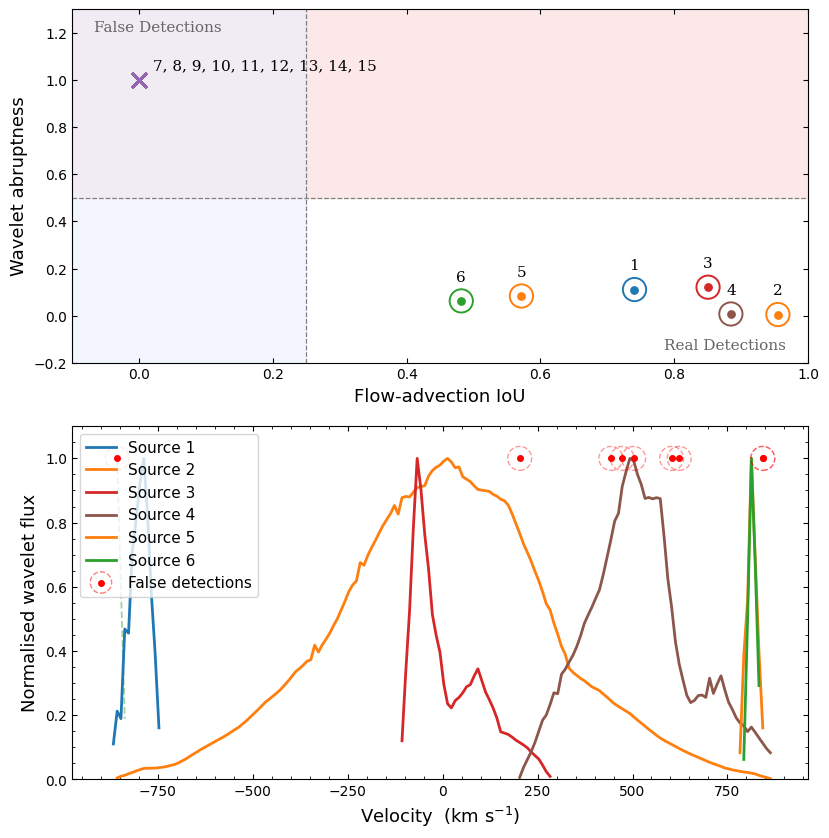

In [16]:
detector = WaveletDetector(
    scales=6, k_sigma=5.0, use_scale=4, min_area=10,
    thresh=W2246_THRESH, use_mean_map_sigma=True,
)

tracker = FlowTracker(
    detector=detector,
    min_match_overlap=5,
    max_gap_channels=5,
    min_displacement=3.0,
    wav_abrupt_thresh=0.5, flow_iou_thresh=0.25,
)

result = tracker.run(
    cube,
    channel_list=channel_list,
    vel_array=vel_array,
    results_dir=_RESULTS_DIR,
    plot=True,
    verbose=True,
)


## Unpack Result

In [17]:
detections = result.detections
flow_seq   = result.flow_seq
tracks     = result.tracks
sources    = result.sources          # real sources (false detections removed)
src_data   = result.src_data
src_colors = result.src_colors

frames    = [(d.channel, d.image, d.footprint_masks, d.peaks, d.boxes)
             for d in detections]
flow_data = list(flow_seq)

# Map mask id -> source_id for fast lookup in plots
mask_to_source: dict[int, int] = {}
for t in tracks:
    for ch, mask in t['masks'].items():
        mask_to_source[id(mask)] = t['source_id']

# Chronological source labels (1-based, ordered by first detected channel)
def _first_ch_src(src):
    chs = [ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks']]
    return min(chs) if chs else 9999

_good_chrono  = sorted(sources, key=_first_ch_src)
_chrono_label = {src['id']: i + 1 for i, src in enumerate(_good_chrono)}
_good_ids     = {s['id'] for s in sources}

plt.rcParams.update(plt.rcParamsDefault)
print(f'{len(sources)} real sources  |  {len(result.false_detections)} false detections')


6 real sources  |  9 false detections


## Plotting Helpers

In [18]:
def _footprint_overlay(footprint_masks, H, W, alpha=0.2):
    union = np.zeros((H, W), dtype=bool)
    for m in footprint_masks:
        union |= m
    rgba = np.zeros((H, W, 4), dtype=np.float32)
    rgba[~union] = [0, 0, 0, alpha]
    return rgba


## Detection + Flow GIF

In [19]:
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)

_flow_by_ch = {cr: ff for cr, ct, ff, _ in flow_data}

H, W  = frames[0][1].shape
qs    = 5
ys_q  = np.arange(0, H, qs)
xs_q  = np.arange(0, W, qs)
Xq, Yq = np.meshgrid(xs_q, ys_q)
n_pts   = Xq.size

vmin = min(f[1].min() for f in frames)
vmax = max(f[1].max() for f in frames)
_norm = matplotlib.colors.PowerNorm(gamma=0.8, vmin=vmin, vmax=vmax)

plt.rcParams.update({'font.family': 'serif', 'font.size': 11})

fig = plt.figure(figsize=(8, 5))
gs  = fig.add_gridspec(
    2, 2, height_ratios=[0.04, 1],
    hspace=0.06, wspace=0.03,
    left=0.02, right=0.98, top=0.88, bottom=0.04,
)
ax_cb  = fig.add_subplot(gs[0, :])
ax_det = fig.add_subplot(gs[1, 0])
ax_flo = fig.add_subplot(gs[1, 1])
for ax in (ax_det, ax_flo):
    ax.set_xticks([]); ax.set_yticks([])

ax_det.text(0.04, 0.96, 'Detections', transform=ax_det.transAxes,
            va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
ax_flo.text(0.04, 0.96, 'Optical Flow', transform=ax_flo.transAxes,
            va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))

_first_good = [m for m in frames[0][2]
               if mask_to_source.get(id(m), -1) in _good_ids]

im_l = ax_det.imshow(frames[0][1], cmap='inferno', norm=_norm, origin='lower')
im_r = ax_flo.imshow(frames[0][1], cmap='inferno', norm=_norm, origin='lower')
ov   = ax_det.imshow(_footprint_overlay(_first_good, H, W),
                     origin='lower', interpolation='nearest')

quiv = ax_flo.quiver(
    Xq.ravel(), Yq.ravel(), np.zeros(n_pts), np.zeros(n_pts), np.zeros(n_pts),
    cmap='cool', angles='xy', scale_units='xy', scale=1,
    width=0.003, headwidth=4, headlength=5, alpha=0.9, clim=(0, 3),
)

_sm = plt.cm.ScalarMappable(cmap='inferno', norm=_norm)
_cb = fig.colorbar(_sm, cax=ax_cb, orientation='horizontal')
_cb.ax.tick_params(labelsize=10, direction='out')
_cb.set_label('Jy beam$^{-1}$', fontsize=12, labelpad=8)
ax_cb.xaxis.set_ticks_position('top')
ax_cb.xaxis.set_label_position('top')

_ch_text = ax_det.text(0.98, 0.03, '', transform=ax_det.transAxes,
                       va='bottom', ha='right', fontsize=12, color='white',
                       fontfamily='serif',
                       bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.45, ec='none'))

_sb_kpc_gif = 15.0
_sb_px_gif  = _sb_kpc_gif / pixscale_kpc
_sb_x0_gif  = W * 0.70
_sb_y0_gif  = H * 0.07
ax_flo.plot([_sb_x0_gif, _sb_x0_gif + _sb_px_gif], [_sb_y0_gif, _sb_y0_gif],
            color='white', lw=1.5, zorder=5)
ax_flo.text(_sb_x0_gif + _sb_px_gif / 2, H * 0.12, f'{_sb_kpc_gif:.1f} kpc',
            color='white', ha='center', va='bottom', fontsize=10,
            fontfamily='serif', zorder=5)

_contours, _markers, _bboxes, _blabels = [], [], [], []
_PAD_BB = 4

def _light(color):
    c = np.array(matplotlib.colors.to_rgb(color))
    return tuple(0.3 * c + 0.7)

def _draw_flow_boxes(footprint_masks, peaks):
    for i, mask in enumerate(footprint_masks):
        sid = mask_to_source.get(id(mask), -1)
        if sid not in _good_ids: continue
        color  = src_colors.get(sid, (1,1,1,1))
        lcolor = _light(color)
        rows, cols = np.where(mask)
        if len(rows) == 0: continue
        r0, r1 = int(rows.min()), int(rows.max())
        c0, c1 = int(cols.min()), int(cols.max())
        clbl = str(_chrono_label.get(sid, sid + 1))
        for _ax, _alpha in [(ax_flo, 1.0), (ax_det, 0.35)]:
            rect = mpatches.Rectangle(
                (c0 - _PAD_BB, r0 - _PAD_BB),
                c1 - c0 + 2*_PAD_BB, r1 - r0 + 2*_PAD_BB,
                linewidth=0.8, edgecolor=lcolor, facecolor='none',
                alpha=_alpha, zorder=4)
            _ax.add_patch(rect)
            _bboxes.append(rect)
            bl = _ax.text(
                c1 + _PAD_BB, r1 + _PAD_BB, clbl,
                ha='center', va='center', fontsize=7,
                color='black', fontweight='bold', fontfamily='serif',
                bbox=dict(boxstyle='circle,pad=0.22', fc=lcolor, ec=lcolor, lw=1.2),
                zorder=6)
            _blabels.append(bl)

def _update(fi):
    ch, img, footprint_masks, peaks, _ = frames[fi]
    im_l.set_data(img); im_r.set_data(img)
    good_masks = [m for m in footprint_masks
                  if mask_to_source.get(id(m), -1) in _good_ids]
    ov.set_data(_footprint_overlay(good_masks, H, W))
    for cs in _contours: cs.remove()
    _contours.clear()
    for mk in _markers: mk.remove()
    _markers.clear()
    for bb in _bboxes: bb.remove()
    _bboxes.clear()
    for bl in _blabels: bl.remove()
    _blabels.clear()
    for i, mask in enumerate(footprint_masks):
        sid = mask_to_source.get(id(mask), -1)
        if sid not in _good_ids: continue
        color = src_colors.get(sid, (1, 1, 1, 1))
        cs = ax_det.contour(mask.astype(float), [0.5], colors=[color], linewidths=0.7)
        _contours.append(cs)
        if i < len(peaks):
            yy, xx = peaks[i]
            mk, = ax_det.plot(xx, yy, marker='+', ms=7, mew=1.0,
                              color=color, linestyle='none')
            _markers.append(mk)
    _draw_flow_boxes(footprint_masks, peaks)
    if ch in _flow_by_ch:
        ff    = _flow_by_ch[ch]
        v_q   = ff[0][ys_q[:, None], xs_q[None, :]].ravel()
        u_q   = ff[1][ys_q[:, None], xs_q[None, :]].ravel()
        mag_q = np.hypot(u_q, v_q)
        pk_m  = float(mag_q.max())
        if pk_m > 1e-6:
            quiv.set_UVC(u_q * qs * 0.8 / pk_m, v_q * qs * 0.8 / pk_m, mag_q)
        else:
            quiv.set_UVC(np.zeros(n_pts), np.zeros(n_pts), np.zeros(n_pts))
    else:
        quiv.set_UVC(np.zeros(n_pts), np.zeros(n_pts), np.zeros(n_pts))
    _v = float(vel_array[ch])
    _ch_text.set_text(f'ch {ch}  |  {_v:.0f} km/s')
    return [im_l, im_r, ov, _ch_text]

_ani = animation.FuncAnimation(fig, _update, frames=len(frames), interval=300, blit=False)
_ani.save(f'{_RESULTS_DIR}/detections_flow.gif', writer='pillow', fps=8)
plt.close(fig)
print(f'Saved {_RESULTS_DIR}/detections_flow.gif  ({len(frames)} frames)')
plt.rcParams.update(plt.rcParamsDefault)


Saved ../results/w2246_288/detections_flow.gif  (183 frames)


## Full-Field Moment Maps

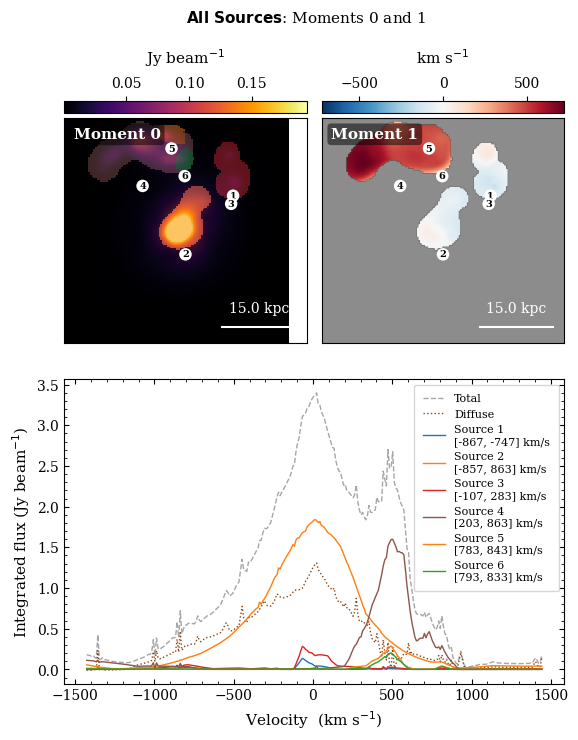

In [20]:
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

_nH, _nW = cube.shape[1], cube.shape[2]
_scalebar_kpc = 15
_scalebar_px  = _scalebar_kpc / pixscale_kpc

# Union footprint per source
_src_union = {}
for src in sources:
    m = np.zeros((_nH, _nW), dtype=bool)
    for t in tracks:
        if t['id'] in src['track_ids']:
            for mask in t['masks'].values():
                m |= mask
    _src_union[src['id']] = m

_all_union = np.zeros((_nH, _nW), dtype=bool)
for m in _src_union.values():
    _all_union |= m

# Moment 0
_det_chs_all = sorted({
    ch for src in sources for t in tracks
    if t['id'] in src['track_ids'] for ch in t['masks']
})
_det_idx   = np.array(_det_chs_all) if _det_chs_all else np.array(channel_list)
_mom0_full = cube[_det_idx].sum(axis=0)

# Moment 1
_flux_stack = cube[_det_idx]
_total_flux = _flux_stack.sum(axis=0)
with np.errstate(invalid='ignore', divide='ignore'):
    _mom1_full = np.where(
        (_total_flux > 0) & _all_union,
        (_flux_stack * vel_array[_det_idx][:, None, None]).sum(axis=0) / _total_flux,
        np.nan,
    )

# RGBA source overlay
_rgba = np.zeros((_nH, _nW, 4), dtype=np.float32)
_rgba[~_all_union] = [0, 0, 0, 0.6]
for src in _good_chrono:
    m = _src_union[src['id']]
    if not m.any(): continue
    r, g, b = matplotlib.colors.to_rgb(src_colors[src['id']])
    _rgba[m] = [r, g, b, 0.45]

fig = plt.figure(figsize=(5.5, 7.5))
gs  = fig.add_gridspec(
    2, 2, height_ratios=[1, 1.1],
    hspace=0.01, wspace=0.06,
    left=0.06, right=0.97, top=0.86, bottom=0.08,
)
ax_m0 = fig.add_subplot(gs[0, 0])
ax_m1 = fig.add_subplot(gs[0, 1])
ax_sp = fig.add_subplot(gs[1, :])

fig.text(0.5, 0.962, r'$\mathbf{All\ Sources}$: Moments 0 and 1',
         ha='center', fontsize=11, fontfamily='serif')

# Moment 0
_v0p, _v1p = np.nanpercentile(_mom0_full, [1, 99])
_im0 = ax_m0.imshow(_mom0_full, cmap='inferno', origin='lower', vmin=_v0p, vmax=_v1p)
ax_m0.imshow(_rgba, origin='lower', interpolation='nearest')
ax_m0.set_xticks([]); ax_m0.set_yticks([])
ax_m0.text(0.04, 0.96, 'Moment 0', transform=ax_m0.transAxes,
           va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
           fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
cb0 = fig.colorbar(_im0, ax=ax_m0, location='top', fraction=0.05, pad=0.02)
cb0.ax.tick_params(labelsize=10, direction='out')
cb0.set_label('Jy beam$^{-1}$', fontsize=11, labelpad=10)

_sb_x0 = _nW * 0.70
_sb_y0 = _nH * 0.07
ax_m0.plot([_sb_x0, _sb_x0 + _scalebar_px], [_sb_y0, _sb_y0], color='white', lw=1.5)
ax_m0.text(_sb_x0 + _scalebar_px / 2, _nH * 0.12, f'{_scalebar_kpc:.1f} kpc',
           color='white', ha='center', va='bottom', fontsize=10, fontfamily='serif')

# Moment 1
ax_m1.set_facecolor('0.55')
_mom1_show = np.where(_all_union, _mom1_full, np.nan)
_m1_vmax   = float(np.nanmax(np.abs(_mom1_show)))
_im1 = ax_m1.imshow(_mom1_show, cmap='RdBu_r', origin='lower',
                    vmin=-_m1_vmax, vmax=_m1_vmax)
ax_m1.set_xticks([]); ax_m1.set_yticks([])
ax_m1.text(0.04, 0.96, 'Moment 1', transform=ax_m1.transAxes,
           va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
           fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
cb1 = fig.colorbar(_im1, ax=ax_m1, location='top', fraction=0.05, pad=0.02)
cb1.ax.tick_params(labelsize=10, direction='out')
cb1.set_label('km s$^{-1}$', fontsize=11, labelpad=10)
ax_m1.plot([_sb_x0, _sb_x0 + _scalebar_px], [_sb_y0, _sb_y0], color='white', lw=1.5)
ax_m1.text(_sb_x0 + _scalebar_px / 2, _nH * 0.12, f'{_scalebar_kpc:.1f} kpc',
           color='white', ha='center', va='bottom', fontsize=10, fontfamily='serif')

# Source number circles
for src in _good_chrono:
    m = _src_union[src['id']]
    if not m.any(): continue
    _rows, _cols = np.where(m)
    _cx_s, _cy_s = _cols.mean(), _rows.mean()
    _ly = _rows.min() - 3
    _lbl = str(_chrono_label[src['id']])
    for _ax in (ax_m0, ax_m1):
        _ax.text(_cx_s, _ly, _lbl, ha='center', va='center', fontsize=7,
                 color='black', fontweight='bold', fontfamily='serif',
                 bbox=dict(boxstyle='circle,pad=0.18', fc='white', ec='none'), zorder=6)

# Spectrum
_total_spec   = cube.sum(axis=(1, 2))
_src_sum_spec = sum(
    cube[:, _src_union[src['id']]].sum(axis=1)
    for src in _good_chrono if _src_union[src['id']].any()
)
_diffuse_spec = _total_spec - _src_sum_spec

ax_sp.plot(vel_array, _total_spec,   color='0.65', lw=1, ls='--', zorder=2)
ax_sp.plot(vel_array, _diffuse_spec, color='saddlebrown', lw=1, ls=':', zorder=2)
for src in _good_chrono:
    if not _src_union[src['id']].any(): continue
    _src_spec = cube[:, _src_union[src['id']]].sum(axis=1)
    ax_sp.plot(vel_array, _src_spec, color=src_colors[src['id']], lw=1, zorder=3)

ax_sp.set_xlabel('Velocity  (km s$^{-1}$)', fontsize=11)
ax_sp.set_ylabel('Integrated flux (Jy beam$^{-1}$)', fontsize=11)
ax_sp.tick_params(which='both', direction='in', top=True, right=True)
ax_sp.minorticks_on()

_leg = [
    Line2D([0], [0], color='0.65',        lw=1, ls='--', label='Total'),
    Line2D([0], [0], color='saddlebrown', lw=1, ls=':',  label='Diffuse'),
]
for src in _good_chrono:
    if not _src_union[src['id']].any(): continue
    det_chs = sorted(ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks'])
    _vlbl = (f'[{vel_array[det_chs[0]]:.0f}, {vel_array[det_chs[-1]]:.0f}] km/s'
             if det_chs else 'no det')
    _leg.append(Line2D([0], [0], color=src_colors[src['id']], lw=1,
                       label=f'Source {_chrono_label[src["id"]]}\n{_vlbl}'))
ax_sp.legend(handles=_leg, fontsize=8, borderpad=0.8, labelspacing=0.5)

plt.savefig(f'{_RESULTS_DIR}/fullfield_moments.png', dpi=130, bbox_inches='tight')
plt.savefig(f'{_RESULTS_DIR}/fullfield_moments.pdf', dpi=130, bbox_inches='tight')
plt.show()
plt.rcParams.update(plt.rcParamsDefault)


## Per-Source Diagnostic Plots

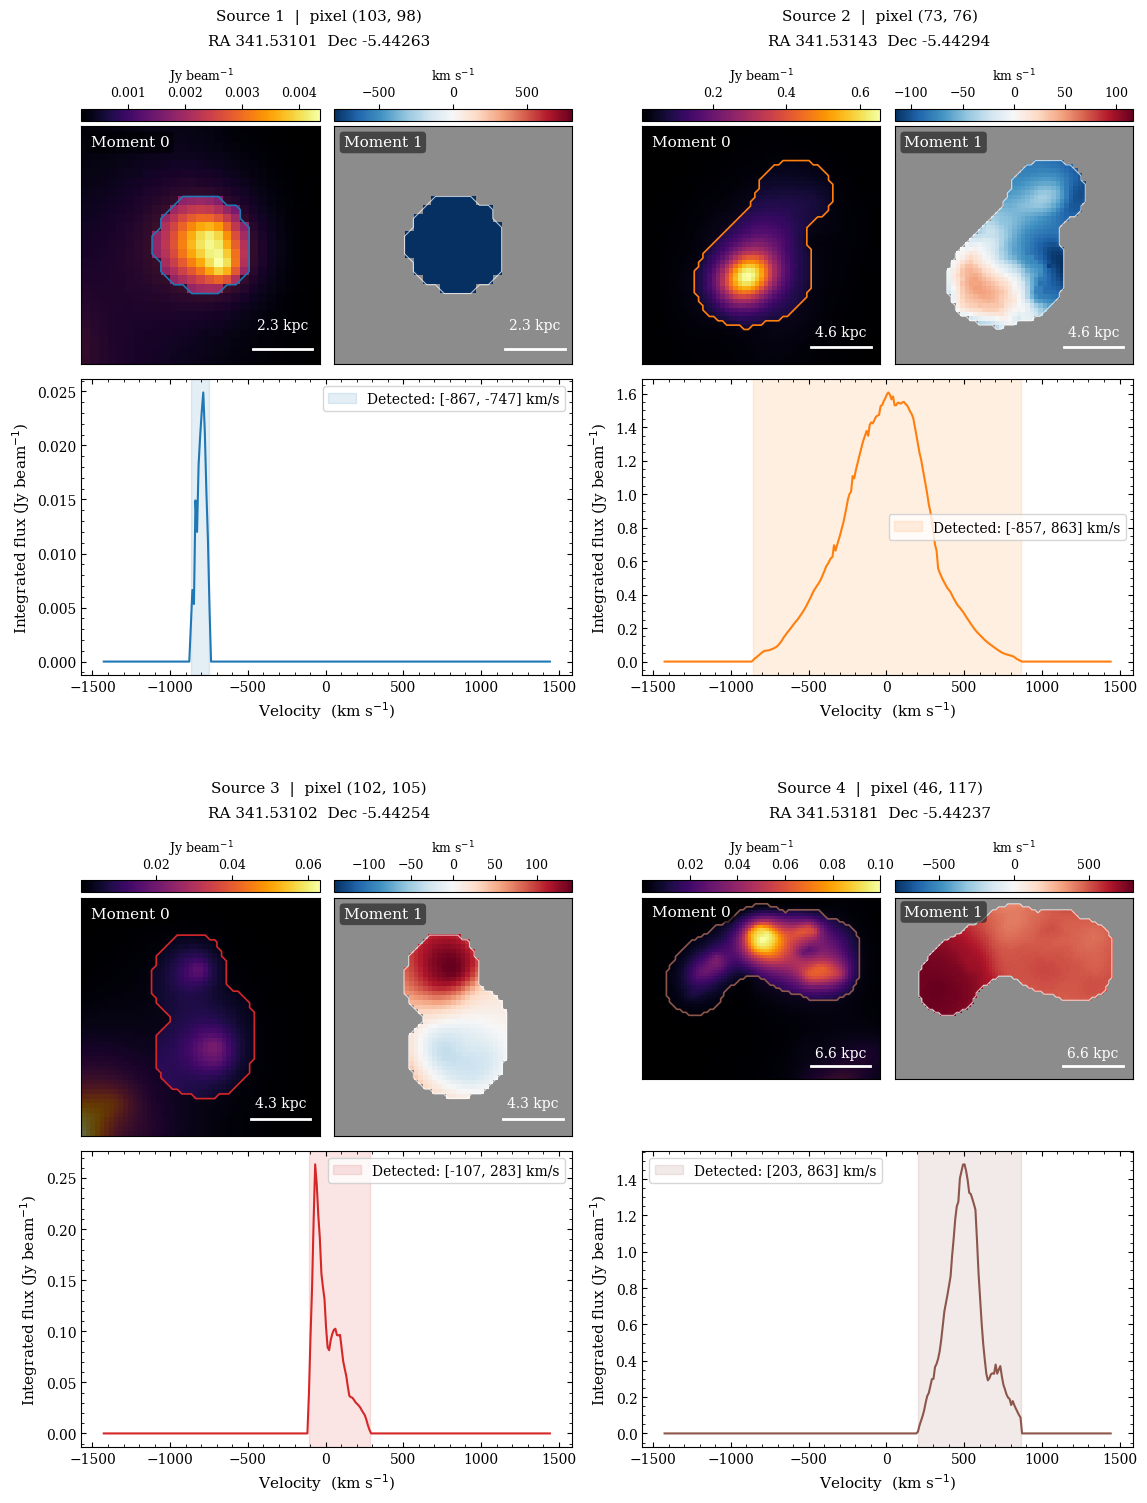

Saved ../results/w2246_288/sources_diag_page1.png


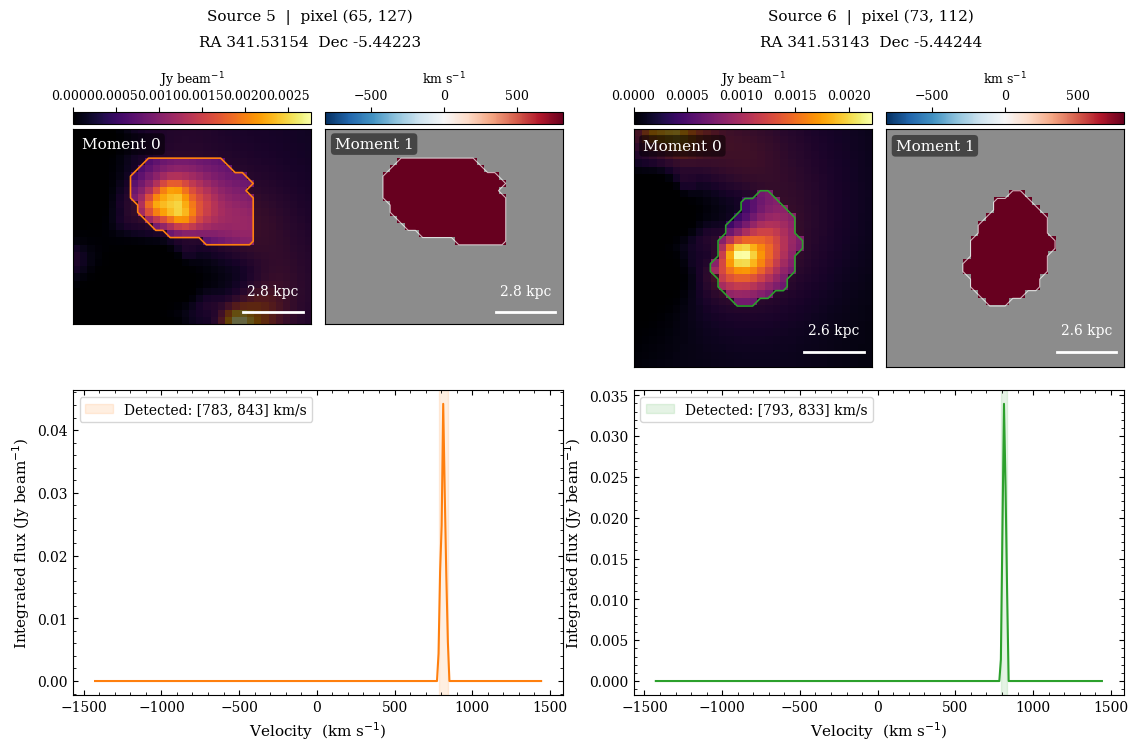

Saved ../results/w2246_288/sources_diag_page2.png


In [21]:
import math

Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

_PAD  = 8
_nH, _nW = cube.shape[1], cube.shape[2]

def _plot_source_diag(src, subfig):
    src_tracks_here = [t for t in tracks if t['id'] in src['track_ids']]
    union_mask = np.zeros((_nH, _nW), dtype=bool)
    ch_to_mask = {}
    for t in src_tracks_here:
        for ch, mask in t['masks'].items():
            union_mask |= mask
            ch_to_mask[ch] = ch_to_mask.get(ch, np.zeros((_nH, _nW), dtype=bool)) | mask
    if not union_mask.any():
        return
    det_channels = sorted(ch_to_mask.keys())

    rows_nz = np.where(union_mask.any(axis=1))[0]
    cols_nz = np.where(union_mask.any(axis=0))[0]
    cy   = (int(rows_nz[0]) + int(rows_nz[-1])) // 2
    cx   = (int(cols_nz[0]) + int(cols_nz[-1])) // 2
    half = max(int(rows_nz[-1]) - int(rows_nz[0]),
               int(cols_nz[-1]) - int(cols_nz[0])) // 2 + _PAD
    y0 = max(0, cy - half);  y1 = min(_nH, cy + half + 1)
    x0 = max(0, cx - half);  x1 = min(_nW, cx + half + 1)

    det_idx        = np.array(det_channels)
    footprint_crop = union_mask[y0:y1, x0:x1]
    mom0_crop      = cube[det_idx].sum(axis=0)[y0:y1, x0:x1]
    flux_crop      = cube[det_idx][:, y0:y1, x0:x1]
    total_flux     = flux_crop.sum(axis=0)
    with np.errstate(invalid='ignore', divide='ignore'):
        mom1_show = np.where(
            (total_flux > 0) & footprint_crop,
            (flux_crop * vel_array[det_idx][:, None, None]).sum(axis=0) / total_flux,
            np.nan,
        )

    spec_chs  = np.arange(cube.shape[0])
    spec_flux = np.array([
        float(cube[ch][ch_to_mask[ch]].sum()) if ch in ch_to_mask else 0.0
        for ch in spec_chs
    ])

    color = src_colors[src['id']]
    gs    = subfig.add_gridspec(2, 2, height_ratios=[1, 1.1],
                                hspace=0.01, wspace=0.06,
                                left=0.06, right=0.97, top=0.86, bottom=0.08)
    ax_m0 = subfig.add_subplot(gs[0, 0])
    ax_m1 = subfig.add_subplot(gs[0, 1])
    ax_sp = subfig.add_subplot(gs[1, :])

    _ov0 = np.zeros(footprint_crop.shape + (4,), dtype=np.float32)
    _ov0[~footprint_crop] = [0, 0, 0, 0.6]
    im0 = ax_m0.imshow(mom0_crop, cmap='inferno', origin='lower')
    ax_m0.imshow(_ov0, origin='lower', interpolation='nearest')
    ax_m0.contour(footprint_crop.astype(float), [0.5], colors=[color], linewidths=1.2)
    ax_m0.set_xticks([]); ax_m0.set_yticks([])
    ax_m0.text(0.04, 0.96, 'Moment 0', transform=ax_m0.transAxes,
               va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
               bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
    cb0 = subfig.colorbar(im0, ax=ax_m0, location='top', fraction=0.05, pad=0.02)
    cb0.ax.tick_params(labelsize=9, direction='out')
    cb0.set_label('Jy beam$^{-1}$', fontsize=9)

    ax_m1.set_facecolor('0.55')
    _m1v = float(np.nanmax(np.abs(mom1_show)))
    im1 = ax_m1.imshow(mom1_show, cmap='RdBu_r', origin='lower',
                       vmin=-_m1v, vmax=_m1v)
    ax_m1.contour(footprint_crop.astype(float), [0.5],
                  colors='white', linewidths=0.8, alpha=0.7)
    ax_m1.set_xticks([]); ax_m1.set_yticks([])
    ax_m1.text(0.04, 0.96, 'Moment 1', transform=ax_m1.transAxes,
               va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
               bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
    cb1 = subfig.colorbar(im1, ax=ax_m1, location='top', fraction=0.05, pad=0.02)
    cb1.ax.tick_params(labelsize=9, direction='out')
    cb1.set_label('km s$^{-1}$', fontsize=9)

    ax_sp.plot(vel_array[spec_chs], spec_flux, color=color, lw=1.5)
    _v0_det = float(vel_array[det_channels[0]])
    _v1_det = float(vel_array[det_channels[-1]])
    ax_sp.axvspan(min(_v0_det, _v1_det), max(_v0_det, _v1_det),
                  alpha=0.12, color=color,
                  label=f'Detected: [{_v0_det:.0f}, {_v1_det:.0f}] km/s')
    ax_sp.set_xlabel('Velocity  (km s$^{-1}$)', fontsize=11)
    ax_sp.set_ylabel('Integrated flux (Jy beam$^{-1}$)', fontsize=11)
    ax_sp.tick_params(which='both', direction='in', top=True, right=True)
    ax_sp.minorticks_on()
    ax_sp.legend(fontsize=10)

    _bw_kpc = (x1 - x0) * pixscale_kpc
    _sb_kpc = _bw_kpc * 0.25
    _sb_px  = _sb_kpc / pixscale_kpc
    _sb_x0  = (x1 - x0) * 0.70
    _sb_y0  = (y1 - y0) * 0.08 - 1
    for _sax in (ax_m0, ax_m1):
        _sax.plot([_sb_x0, _sb_x0 + _sb_px], [_sb_y0, _sb_y0], color='white', lw=2)
        _sax.text(_sb_x0 + _sb_px / 2, _sb_y0 + 2, f'{_sb_kpc:.1f} kpc',
                  color='white', ha='center', va='bottom', fontsize=10, fontfamily='serif')

    _ra, _dec = _wcs2d.all_pix2world([[cx, cy]], 0)[0]
    subfig.text(0.5, 0.979,
                f'Source {_chrono_label[src["id"]]}  |  pixel ({cx}, {cy})',
                ha='center', fontsize=11, fontfamily='serif')
    subfig.text(0.5, 0.945,
                f'RA {_ra:.5f}  Dec {_dec:.5f}',
                ha='center', fontsize=11, fontfamily='serif')

_src_chunks = [sources[i:i+4] for i in range(0, len(sources), 4)]
for _ci, chunk in enumerate(_src_chunks):
    n     = len(chunk)
    nrows = math.ceil(n / 2)
    ncols = min(n, 2)
    fig   = plt.figure(figsize=(ncols * 5.5, nrows * 7.5))
    sfs   = fig.subfigures(nrows, ncols, wspace=0.04, hspace=0.06)
    import numpy as _np2
    sfs_flat = _np2.array(sfs).flatten()
    for src, sf in zip(chunk, sfs_flat):
        _plot_source_diag(src, sf)
    for sf in sfs_flat[n:]:
        sf.set_visible(False)
    fname = f'{_RESULTS_DIR}/sources_diag_page{_ci+1}'
    plt.savefig(fname + '.png', dpi=130, bbox_inches='tight')
    plt.savefig(fname + '.pdf', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}.png')

plt.rcParams.update(plt.rcParamsDefault)


## Kinematic Trajectories

In [ ]:
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

_good_tracks = [t for t in tracks if t['source_id'] in _good_ids]

mean_img = cube[channel_list[len(channel_list)//2 - 2] :
                channel_list[len(channel_list)//2 + 3]].mean(axis=0)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(mean_img, cmap='inferno', origin='lower')
ax.set_xlabel('Pixel X', fontsize=11)
ax.set_ylabel('Pixel Y', fontsize=11)
ax.tick_params(which='both', direction='in', top=True, right=True)
fig.text(0.5, 0.98, r'$\mathbf{Sources}$: Kinematic Trajectories',
         ha='center', fontsize=11, fontfamily='serif')

for t in _good_tracks:
    sid   = t['source_id']
    color = src_colors[sid]
    clbl  = _chrono_label[sid]
    ys_t  = [p[1] for p in t['trajectory']]
    xs_t  = [p[2] for p in t['trajectory']]
    lw    = 1.8 if t['kinematic'] else 0.8
    alpha = 0.95 if t['kinematic'] else 0.4
    ax.plot(xs_t, ys_t, color=color, lw=lw, alpha=alpha)
    ax.scatter(xs_t[0],  ys_t[0],  s=40, color=color, zorder=5, marker='o', alpha=alpha)
    ax.scatter(xs_t[-1], ys_t[-1], s=60, color=color, zorder=5, marker='^', alpha=alpha)
    ax.text(xs_t[0], ys_t[0] - 4, str(clbl), color='black',
            fontsize=7, ha='center', va='top', fontfamily='serif',
            bbox=dict(boxstyle='circle,pad=0.18', fc='white', ec='none'), zorder=6)
    for ch_sp in t['split_at']:
        for ch, sy, sx in t['trajectory']:
            if ch == ch_sp:
                ax.plot(sx, sy, marker='*', ms=12, color=color, zorder=6)
                break
    for ch_mg, _ in t['merge_into']:
        for ch, sy, sx in t['trajectory']:
            if ch == ch_mg:
                ax.plot(sx, sy, marker='D', ms=8, color=color, zorder=6, alpha=0.7)
                break

_patches = [mpatches.Patch(color=src_colors[s['id']],
                            label=f'Source {_chrono_label[s["id"]]}')
            for s in _good_chrono]
ax.legend(handles=_patches, loc='upper right', fontsize=9,
          framealpha=0.75, edgecolor='0.3')

plt.tight_layout()
plt.savefig(f'{_RESULTS_DIR}/trajectories.png', dpi=130, bbox_inches='tight')
plt.savefig(f'{_RESULTS_DIR}/trajectories.pdf', dpi=130, bbox_inches='tight')
plt.show()
print('Saved trajectories.png')
plt.rcParams.update(plt.rcParamsDefault)
